<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/05_1_%EA%B5%90%EC%B0%A8_%EA%B2%80%EC%A6%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- **교차 검증**(cross-validation)
  - 훈련 세트와 테스트 세트로 한 번 나누는 것보다 더 안정적이고 뛰어난 통계적 평가 방법
  - 데이터를 여러 번 반복해서 나누고 여러 모델을 학습
- **k-겹 교차 검증**(k-fold cross-validation)
  - $k$는 보통 5또는 10
  - 1️⃣ 데이터를 **폴드**(fold)라고 하는 (거의) 비슷한 크기의 부분 집합 다섯 개로 나눔
  - 2️⃣ 일련의 모델들을 만듦
    - $k$가 5라면...
    - 첫 번째 모델: 폴드1을 데스트 세트 / 나머지 폴드를 훈련 세트
    - 두 번째 모델: 폴드2를 테스트 세트 / 폴드 1, 3, 4, 5를 훈련 세트
    - ...
  - 3️⃣ 분할마다 정확도를 측정 ($k$가 5라면 다섯 개의 정확도 값)

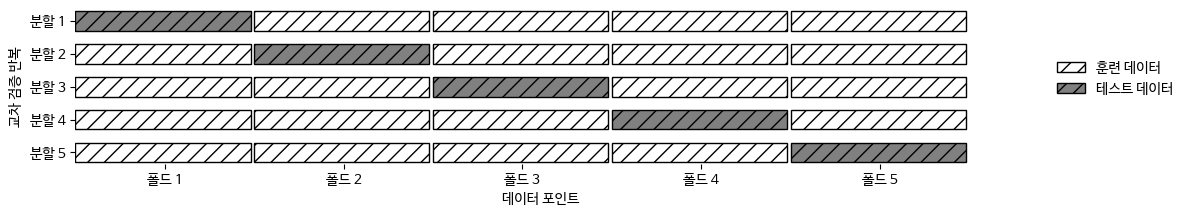

In [3]:
# 5-겹 교차 검증에서의 데이터 분할
mglearn.plots.plot_cross_validation()

## 01 scikit-learn의 교차 검증

In [5]:
# cross_val_score()
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target)
print(f"교차 검증 점수: {scores}") # 5-fold 교차 검증

교차 검증 점수: [0.967 1.    0.933 0.967 1.   ]


In [6]:
scores = cross_val_score(logreg, iris.data, iris.target,
                         cv=10) # 10-fold 교차 검증
print(f"교차 검증 점수: {scores}")

교차 검증 점수: [1.    0.933 1.    1.    0.933 0.933 0.933 1.    1.    1.   ]


In [8]:
print(f"교차 검증 평균 점수: {round(scores.mean(), 2)}")

교차 검증 평균 점수: 0.97


- 10-fold 교차 검증의 값들은 100%에서 93%까지 폴드에 따라 비교적 차이가 큼 👉 모델이 훈련에 사용한 폴드에 매우 의존적이거나 데이터셋이 작기 때문일 수 있음

In [9]:
# cross_validate(): 분할마다 훈련과 테스트에 걸린 시간을 담은 딕셔너리 반환
from sklearn.model_selection import cross_validate

res = cross_validate(logreg, iris.data, iris.target,
                     return_train_score=True)

res

{'fit_time': array([0.108, 0.191, 0.211, 0.019, 0.019]),
 'score_time': array([0.004, 0.004, 0.001, 0.001, 0.001]),
 'test_score': array([0.967, 1.   , 0.933, 0.967, 1.   ]),
 'train_score': array([0.967, 0.967, 0.983, 0.983, 0.975])}

In [12]:
res_df = pd.DataFrame(res)
print(f"평균 시간과 점수:\n{res_df.mean()}")
res_df

평균 시간과 점수:
fit_time       1.10e-01
score_time     2.10e-03
test_score     9.73e-01
train_score    9.75e-01
dtype: float64


,fit_time,score_time,test_score,train_score
0,0.11,3.52e-03,0.97,0.97
1,0.19,3.52e-03,1.00,0.97
2,0.21,1.15e-03,0.93,0.98
3,0.02,1.16e-03,0.97,0.98
4,0.02,1.11e-03,1.00,0.97


## 02 교차 검증의 장점
- `train_test_split()`은 데이터를 무작위로 나누지만, 교차 검증은 테스트 세트에 각 샘플이 정확하게 한 번씩 들어감: 각 샘플은 폴드 중 하나에 속하며 각 폴드는 한 번씩 테스트 세트가 됨
- 교차 검증의 점수를 높이기 위해서는 데이터셋에 있는 모든 샘플에 대해 모델이 잘 일반화되어야 함
- 모델이 훈련 데이터에 얼마나 민감한지 알 수 있음
- 분할을 한 번 했을 때보다 데이터를 더 효과적으로 사용할 수 있음
- 단점: 늘어나는 연산 비용 ($k$배 느림)
- ⚠️⚠️ 교차 검증은 새로운 데이터에 적용할 모델을 만드는 방법이 아님!! 👉 모델을 반환하지 않음

## 03 계층별 k-겹 교차 검증과 그외 전략들

In [13]:
iris = load_iris()
print(f"Iris 레이블:\n{iris.target}")

Iris 레이블:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


- 3-fold 교차 검증을 적용한다고 했을 때, 첫 번째 반복에서 테스트 세트는 클래스 0만을, 두 번째 반복에서 테스트 세트는 클래스 1만을, 세 번째 반복에서는 클래스 2만을 가지게 됨 ➡️ 정확도는 0이 됨
- **계층별 k-겹 교차 검증** (stratified k-fold cross-validation)
  - 분류 문제일 경우 사용
  - 폴드 안의 클래스 비율이 전체 데이터셋의 클래스 비율과 같도록 데이터를 나눔
  - `cross_val_score()`에서는 기본적으로 분류에서는 StratifiedKFold, 회귀에서는 단순한 KFold를 적용

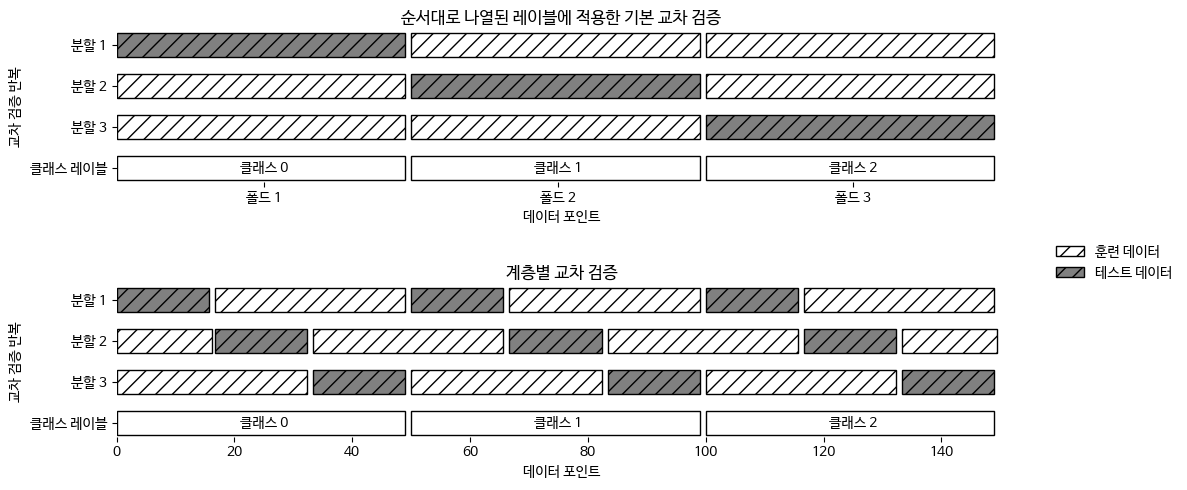

In [14]:
# 클래스 레이블 순서대로 정렬된 데이터에서 기본 교차 검증과 계층별 교차 검증의 비교
mglearn.plots.plot_stratified_cross_validation()

### 3.1 교차 검증 상세 옵션
- `cross_val_score()`의 `cv` 매개변수에 **교차 검증 분할기**(cross-validation splitter)를 전달함으로써 데이터를 분할할 때 더 세밀하게 제어 가능
- 대부분 회귀에서는 k-겹 교차 검증, 분류에서는 계층별 k-겹 교차 검증의 기본값이 잘 작동
- 하지만 다른 전략이 필요할 때가 있음
  - e.g. 다른 사람의 결과를 재현하기 위해 분류 문제에서 기본 K-Fold를 사용하는 경우

In [15]:
# 분류 문제에 단순 k-fold 사용
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5)

print(f"교차 검증 점수:\n{cross_val_score(logreg, iris.data, iris.target,\
                                    cv=kfold)}")

교차 검증 점수:
[1.    1.    0.867 0.933 0.833]


In [16]:
# iris 데이터셋에 3-겹 교차 검증을 사용

kfold = KFold(n_splits=3)

print(f"교차 검증 점수:\n{cross_val_score(logreg, iris.data, iris.target,\
                                    cv=kfold)}")

교차 검증 점수:
[0. 0. 0.]


In [17]:
# 기본 k-fold에 데이터 섞기

kfold = KFold(n_splits=3, shuffle=True, random_state=0)

print(f"교차 검증 점수:\n{cross_val_score(logreg, iris.data, iris.target,\
                                    cv=kfold)}")

교차 검증 점수:
[0.98 0.96 0.96]


### 3.2 LOOCV
- LOOCV (Leave-one-out cross-validation)
- 폴드 하나에 샘플 하나만 들어 있는 k-겹 교차 검증
- 각 반복에서 하나의 데이터 포인트를 선택해 테스트 세트로 사용
- 큰 데이터셋에서는 시간이 매우 오래 걸리지만, 작은 데이터셋에서는 더 좋은 결과를 만들어낼 수 있음

In [18]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)

print(f"교차 검증 분할 횟수: {len(scores)}")
print(f"평균 정확도: {round(scores.mean(), 2)}")

교차 검증 분할 횟수: 150
평균 정확도: 0.97


### 3.3 임의 분할 교차 검증
- 임의 분할 교차 검증 (shuffle-split cross-validation)
- `train_size`만큼의 포인트로 훈련 세트를 만들고, `test_size`만큼의 훈련 세트와 중첩되지 않은 포인트로 테스트 세트를 만들도록 분할
- 이 분할은 `n_splits` 횟수만큼 반복
- `train_size`, `test_size`에 정수를 입력하면 포인트의 절대 개수, 실수를 입력하면 전체 데이터에서의 비율

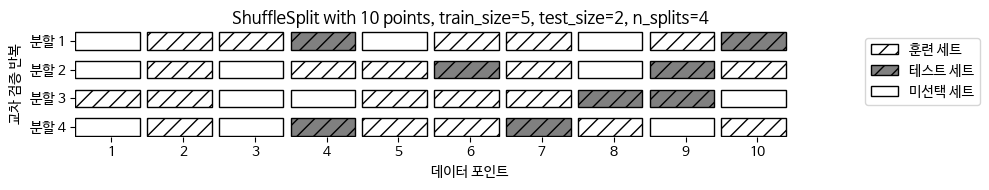

In [19]:
# 10개의 샘플 포인트에 train_size=5, test_size=2, n_splits=4
mglearn.plots.plot_shuffle_split()

In [21]:
from sklearn.model_selection import ShuffleSplit

# 데이터셋의 50%를 훈련 세트로, 50%를 테스트 세트로 10번 반복
shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)

scores = cross_val_score(logreg, iris.data, iris.target,
                         cv=shuffle_split)
print(f"교차 검증 점수:\n{scores}")

교차 검증 점수:
[0.947 0.947 0.947 0.947 0.96  0.96  0.973 0.907 0.96  0.987]


### 3.4 그룹별 교차 검증
- 데이터 안에 매우 연관된 그룹이 있을 때 (e.g. 의료, 음성 등 같은 사람으로부터 여러 샘플을 가지고 있는 경우)
- `GroupKFold`: `groups` 배열을 받아 훈련 세트와 테스트 세트를 만들 때 분리되지 않아야 할 그룹을 지정 (클래스 레이블과 혼동하지 말 것)

In [23]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import GroupKFold

X, y = make_blobs(n_samples=12, random_state=0)

groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3] # 4개의 그룹

scores = cross_val_score(logreg, X, y, groups=groups,
                         cv=GroupKFold(n_splits=3))
print(f"교차 검증 점수:\n{scores}")

교차 검증 점수:
[0.75  0.6   0.667]


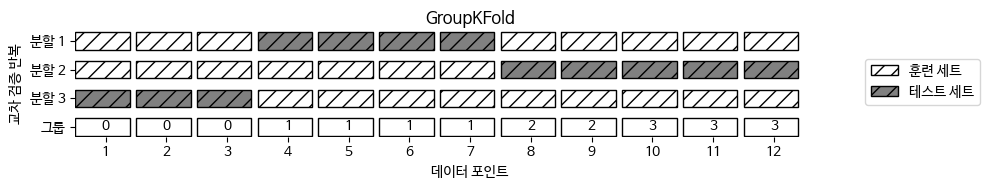

In [24]:
# 레이블에 기반한 GroupKFold 분할
mglearn.plots.plot_group_kfold()

## 04 반복 교차 검증
- 데이터셋의 크기가 크지 않은 경우 교차 검증을 반복하여 여러 번 수행하는 경우
- 회귀에서는 `RepeatedKFold`, 분류에서는 `RepeatedStraitifiedKFold` 사용
- 기본값은 5-겹 교차 검증 (`n_splits`) 수행, 반복 횟수 (`n_repeats`)의 기본값은 10
- 반복할 때마다 데이터를 다시 섞음
- 전체 검증 점수의 개수는 `n_splits` $\times$ `n_repeats`

In [25]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskfold = RepeatedStratifiedKFold(random_state=42)
scores = cross_val_score(logreg, iris.data, iris.target, cv=rskfold)

print(f"교차 검증 점수:\n{scores}")
print(f"교차 검증 평균 점수: {round(scores.mean(), 3)}")

교차 검증 점수:
[1.    0.967 0.933 1.    0.933 0.967 0.967 0.933 1.    0.967 0.933 1.
 1.    0.967 0.967 0.9   1.    1.    0.933 0.967 0.933 0.967 0.967 1.
 0.967 1.    0.967 0.967 0.9   1.    0.967 0.967 0.967 0.967 0.933 0.967
 0.967 1.    1.    0.9   0.967 1.    0.9   0.967 0.967 0.9   0.967 0.967
 1.    0.967]
교차 검증 평균 점수: 0.965
